# EEG_07e — Pre-costruzione Tensori Grafo / Ipergrafo da CSV

Legge i CSV di Paolo (`data/raw_csv/training_set/PXXX_SYYY/parola_img.csv`)
e costruisce tensori PyG `Data(x, edge_index, y, subj, sess)` in `data/interim/graphs/`.

**Struttura CSV**: 61 righe × 384 colonne (canali × campioni), nessun header.

Supporta:
- Metodi connettività: **PCC**, **PLV**, **wPLI**
- K valori per k-NN
- **Pruning**: soglia edge + rimozione canali a bassa connettività
- Costruzione **ipergrafo** (per EEG_11)

In [1]:
# ============================================================
# CONFIGURAZIONE
# ============================================================

# Metodi connettività
METHODS = ["wpli"]           # "pcc" | "plv" | "wpli"

# K-vicini per k-NN graph
K_VALUES = [6]

# Soglia edge: rimuove archi con peso < threshold (0.0 = nessuna)
EDGE_THRESHOLD = 0.0

# Pruning canali: rimuove canali con connettività media < mean - sigma*std
# None = nessun pruning
CHANNEL_PRUNING_SIGMA = None

# Canali da escludere esplicitamente (es. ["A1", "A2"] o [])
CHANNEL_DROP_NAMES = []

# Costruisci anche ipergrafo (per EEG_11)
BUILD_HGNN = True
K_HYPER    = 6

# Schema label da applicare
CLUSTER_SCHEME = "concr4"   # "concr4" | "ward4" | "sem5" | "pos4" | "raw110"

# Forza ricostruzione anche se file già esiste
FORCE_REBUILD = True

print("Config OK")

Config OK


In [2]:
# ============================================================
# IMPORT E PATHS
# ============================================================

import os, sys, json
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import numpy as np
import pandas as pd
import torch
from pathlib import Path
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

from torch_geometric.data import Data

# Trova project root
project_root = next(
    (p for p in [Path().resolve()] + list(Path().resolve().parents)
     if (p / ".git").exists()),
    Path().resolve()
)
sys.path.insert(0, str(project_root / "scripts"))
from utils import load_label_scheme

# Paths
CSV_ROOT   = project_root / "data" / "raw_csv" / "training_set"
GRAPHS_DIR = project_root / "data" / "interim" / "graphs"
CONFIGS    = project_root / "configs" / "label_schemes"
GRAPHS_DIR.mkdir(parents=True, exist_ok=True)

N_CHANS   = 61
N_SAMPLES = 384

# Mapping parola → label_id (da label2idx.json)
with open(CONFIGS / "label2idx.json") as f:
    word2labelid = json.load(f)   # {"accendere": 0, "acqua": 1, ...}

# Schema cluster
labelid2cluster, N_CLASSES, cluster_names = load_label_scheme(CLUSTER_SCHEME, project_root / "data" / "interim")

# Lista cartelle soggetto-sessione
session_dirs = sorted(CSV_ROOT.iterdir())
print(f"Project root  : {project_root}")
print(f"CSV root      : {CSV_ROOT}")
print(f"Cartelle sess : {len(session_dirs)}")  # ~357
print(f"N_CHANS       : {N_CHANS}")
print(f"Schema        : {CLUSTER_SCHEME} ({N_CLASSES} classi)")
print(f"Esempio dir   : {session_dirs[0].name}")

Project root  : /home/daniele_u/miralis-hypergraph-imagined-speech
CSV root      : /home/daniele_u/miralis-hypergraph-imagined-speech/data/raw_csv/training_set
Cartelle sess : 357
N_CHANS       : 61
Schema        : concr4 (4 classi)
Esempio dir   : P000_S001


In [3]:
# ============================================================
# PARSING NOMI CARTELLA
# PXXX_SYYY → subj_id (int), sess_id (int)
# ============================================================

def parse_folder(folder_name: str):
    """Es. 'P003_S002' → (3, 2)"""
    parts = folder_name.split("_")
    subj = int(parts[0][1:])   # rimuove 'P'
    sess = int(parts[1][1:])   # rimuove 'S'
    return subj, sess

def load_csv_trial(csv_path: Path) -> np.ndarray:
    """Legge CSV 61×384 senza header. Restituisce array float32 (61, 384)."""
    return pd.read_csv(csv_path, header=None).values.astype(np.float32)

# Test
test_dir = session_dirs[0]
test_csv = sorted(test_dir.iterdir())[0]
x_test   = load_csv_trial(test_csv)
subj_t, sess_t = parse_folder(test_dir.name)
word_t   = test_csv.stem.replace("_img", "")

print(f"Cartella: {test_dir.name} → subj={subj_t}, sess={sess_t}")
print(f"File    : {test_csv.name} → parola='{word_t}', label_id={word2labelid.get(word_t, '??')}")
print(f"Shape   : {x_test.shape}  (atteso: (61, 384))")
assert x_test.shape == (N_CHANS, N_SAMPLES), f"Shape attesa ({N_CHANS}, {N_SAMPLES}), trovata {x_test.shape}"
print("✅ Parsing OK")

Cartella: P000_S001 → subj=0, sess=1
File    : accendere_img.csv → parola='accendere', label_id=0
Shape   : (61, 384)  (atteso: (61, 384))
✅ Parsing OK


In [4]:
# ============================================================
# FUNZIONI DI CONNETTIVITÀ
# ============================================================

def pcc_matrix(x_np: np.ndarray) -> np.ndarray:
    """Pearson |PCC| tra canali. Shape: (N, N)"""
    pcc = np.abs(np.corrcoef(x_np))
    np.fill_diagonal(pcc, 0.0)
    return pcc


def plv_matrix(x_np: np.ndarray) -> np.ndarray:
    """Phase Locking Value via Hilbert. Shape: (N, N)"""
    from scipy.signal import hilbert
    N = x_np.shape[0]
    phases = np.angle(hilbert(x_np, axis=1))
    plv = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            diff = phases[i] - phases[j]
            plv[i, j] = plv[j, i] = np.abs(np.mean(np.exp(1j * diff)))
    return plv


def wpli_matrix(x_np: np.ndarray) -> np.ndarray:
    """Weighted Phase Lag Index. Shape: (N, N)"""
    from scipy.signal import hilbert
    N = x_np.shape[0]
    analytic = hilbert(x_np, axis=1)
    wpli = np.zeros((N, N))
    for i in range(N):
        for j in range(i + 1, N):
            cs = analytic[i] * np.conj(analytic[j])
            im = np.imag(cs)
            w  = np.abs(im)
            wpli[i, j] = wpli[j, i] = np.abs(np.mean(im * w)) / (np.mean(w) + 1e-9)
    return wpli


def knn_edge_index(matrix: np.ndarray, k: int,
                   threshold: float = 0.0) -> torch.LongTensor:
    """k-NN graph da matrice connettività. Restituisce edge_index (2, E)."""
    N = matrix.shape[0]
    rows, cols = [], []
    for i in range(N):
        row = matrix[i].copy(); row[i] = -1.0
        if threshold > 0.0:
            row[row < threshold] = 0.0
        top_k = np.argsort(row)[-k:]
        for j in top_k:
            if row[j] > 0.0 or threshold == 0.0:
                rows += [i, j]; cols += [j, i]
    return torch.tensor([rows, cols], dtype=torch.long)


def hyperedge_index_fn(x_np: np.ndarray, k: int,
                       threshold: float = 0.0) -> torch.LongTensor:
    """
    Ipergrafo k-NN per-trial basato su PCC.
    Ogni nodo i è centro di un'iperedge con i + top-k vicini.
    """
    pcc = pcc_matrix(x_np)
    N   = pcc.shape[0]
    vertex_list, edge_list = [], []
    for e_id in range(N):
        row = pcc[e_id].copy()
        if threshold > 0.0:
            row[row < threshold] = 0.0
        top_k   = np.argsort(row)[-k:]
        members = [e_id] + [j for j in top_k if (row[j] > 0.0 or threshold == 0.0)]
        for v in members:
            vertex_list.append(v); edge_list.append(e_id)
    return torch.tensor([vertex_list, edge_list], dtype=torch.long)


print("Funzioni connettività OK")

Funzioni connettività OK


Calcolo PCC media su 50 trial (P000_S001)...


  0%|          | 0/50 [00:00<?, ?it/s]

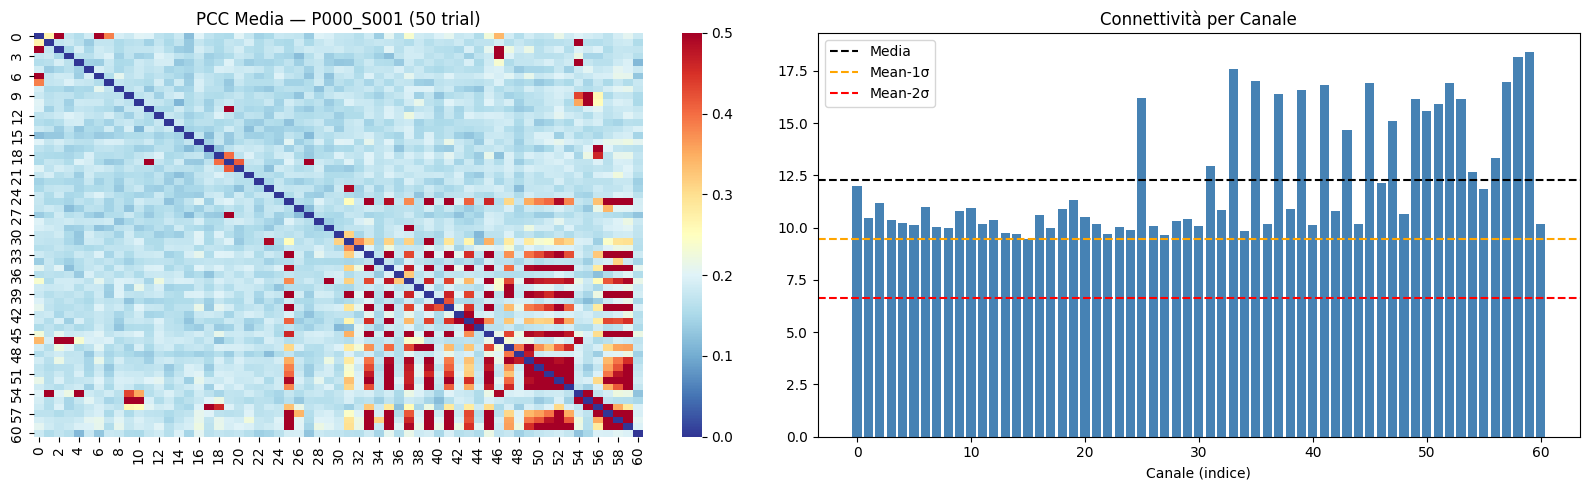


Canali sotto mean-2σ (candidati pruning):


In [5]:
# ============================================================
# ANALISI VISIVA — connettività per canale
# Aiuta a decidere se/cosa prunare
# ============================================================

# Usa primo soggetto come campione
sample_dir = session_dirs[0]
csv_files  = sorted(sample_dir.iterdir())[:50]   # 50 trial campione

print(f"Calcolo PCC media su {len(csv_files)} trial ({sample_dir.name})...")
pcc_sum = np.zeros((N_CHANS, N_CHANS))
for csv_path in tqdm(csv_files):
    x_np = load_csv_trial(csv_path)
    pcc_sum += pcc_matrix(x_np)
pcc_avg = pcc_sum / len(csv_files)

ch_connectivity = pcc_avg.sum(axis=1)
mean_conn = ch_connectivity.mean()
std_conn  = ch_connectivity.std()

# Nomi canali dall'ordine nel CSV (basato su ebneuro.csv se disponibile)
ch_labels = [str(i) for i in range(N_CHANS)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(pcc_avg, ax=axes[0], cmap="RdYlBu_r", vmin=0, vmax=0.5)
axes[0].set_title(f"PCC Media — {sample_dir.name} ({len(csv_files)} trial)")

colors = ["red" if c < mean_conn - 2*std_conn else "steelblue" for c in ch_connectivity]
axes[1].bar(range(N_CHANS), ch_connectivity, color=colors)
axes[1].axhline(mean_conn, color="black", linestyle="--", label="Media")
axes[1].axhline(mean_conn - std_conn, color="orange", linestyle="--", label="Mean-1σ")
axes[1].axhline(mean_conn - 2*std_conn, color="red", linestyle="--", label="Mean-2σ")
axes[1].set_xlabel("Canale (indice)")
axes[1].set_title("Connettività per Canale")
axes[1].legend()

plt.tight_layout()
fig_path = project_root / "figures" / f"eeg07e_connectivity_{sample_dir.name}.png"
fig.savefig(fig_path, dpi=120, bbox_inches="tight")
plt.show()

print("\nCanali sotto mean-2σ (candidati pruning):")
for i, conn in enumerate(ch_connectivity):
    if conn < mean_conn - 2*std_conn:
        print(f"  idx={i:2d}  conn={conn:.4f}")

In [6]:
# ============================================================
# PRUNING CANALI
# ============================================================

# Indici attivi (tutti e 61 di default)
active_idx = list(range(N_CHANS))

# Pruning per sigma
if CHANNEL_PRUNING_SIGMA is not None:
    thresh = mean_conn - CHANNEL_PRUNING_SIGMA * std_conn
    active_idx = [i for i in active_idx if ch_connectivity[i] >= thresh]
    print(f"Pruning σ={CHANNEL_PRUNING_SIGMA}: rimasti {len(active_idx)}/{N_CHANS} canali")

# Pruning per nome (richiede mapping idx→nome se disponibile)
if CHANNEL_DROP_NAMES:
    print(f"Drop esplicito: {CHANNEL_DROP_NAMES} — imposta indici in CHANNEL_DROP_NAMES come indici numerici")

N_ACTIVE = len(active_idx)
print(f"Canali attivi: {N_ACTIVE}/{N_CHANS}")

Canali attivi: 61/61


In [ ]:
# ============================================================
# FUNZIONE HELPER: itera tutti i trial da CSV
# ============================================================

def iter_all_trials():
    """
    Generator: itera tutte le cartelle PXXX_SYYY e tutti i CSV.
    Yields: (x_np, label_id, cluster_id, subj_id, sess_id)
    Salta file con parola non in label2idx o label_id non in labelid2cluster.
    """
    for sess_dir in sorted(CSV_ROOT.iterdir()):
        if not sess_dir.is_dir():
            continue
        subj_id, sess_id = parse_folder(sess_dir.name)
        for csv_path in sorted(sess_dir.iterdir()):
            if csv_path.suffix != ".csv":
                continue
            word = csv_path.stem.replace("_img", "")
            if word not in word2labelid:
                continue
            label_id = word2labelid[word]
            if label_id not in labelid2cluster:
                continue
            cluster_id = labelid2cluster[label_id]
            x_np = load_csv_trial(csv_path)[active_idx, :]   # (N_ACTIVE, 384)
            yield x_np, label_id, cluster_id, subj_id, sess_id

# Conta trial totali
n_total = sum(1 for _ in iter_all_trials())
print(f"Trial totali validi: {n_total}")
print(f"(atteso ~{len(session_dirs) * 110} = {len(session_dirs)} sess × 110 parole)")

Trial totali validi: 38883
(atteso ~39270 = 357 sess × 110 parole)


: 

In [ ]:
import multiprocessing as mp
import torch.multiprocessing as tmp
tmp.set_sharing_strategy("file_system")
from tqdm.auto import tqdm
from scipy.signal import hilbert
import numpy as np
import torch
from torch_geometric.data import Data


# ============================================================
# CONNECTIVITY
# ============================================================

def compute_connectivity_fast(x_np, method):

    N = x_np.shape[0]

    if method == "pcc":
        matrix = np.abs(np.corrcoef(x_np))

    elif method in ["plv", "wpli"]:

        analytic = hilbert(x_np, axis=1)
        phases = np.angle(analytic)

        matrix = np.zeros((N, N), dtype=np.float32)

        if method == "plv":
            for i in range(N):
                diff = phases[i] - phases
                matrix[i] = np.abs(np.mean(np.exp(1j * diff), axis=1))

        elif method == "wpli":
            for i in range(N):
                cs = analytic[i] * np.conj(analytic)
                im = np.imag(cs)
                w = np.abs(im)
                matrix[i] = np.abs(np.mean(im * w, axis=1)) / (np.mean(w, axis=1) + 1e-9)

    np.fill_diagonal(matrix, 0.0)

    return matrix


# ============================================================
# WORKER GRAFO
# ============================================================

def worker_graph(args):

    x_np, method, k, threshold, label_id, cluster_id, subj_id, sess_id = args

    matrix = compute_connectivity_fast(x_np, method)

    N = matrix.shape[0]

    rows, cols = [], []

    for i in range(N):

        row = matrix[i].copy()
        row[i] = -1.0

        if threshold > 0.0:
            row[row < threshold] = 0.0

        top_k = np.argsort(row)[-k:]

        for j in top_k:
            if row[j] > 0.0 or threshold == 0.0:
                rows.append(i)
                cols.append(j)

    edge_index = torch.tensor([rows, cols], dtype=torch.long)

    return Data(
        x=torch.from_numpy(x_np).float(),
        edge_index=edge_index,
        y=torch.tensor(cluster_id),
        label_id=torch.tensor(label_id),
        subj=torch.tensor(subj_id),
        sess=torch.tensor(sess_id),
    )


# ============================================================
# WORKER IPERGRAFO
# ============================================================

def worker_hgraph(args):

    x_np, k, threshold, label_id, cluster_id, subj_id, sess_id = args

    pcc = compute_connectivity_fast(x_np, "pcc")

    N = pcc.shape[0]

    v_list, e_list = [], []

    for e_id in range(N):

        row = pcc[e_id].copy()

        if threshold > 0.0:
            row[row < threshold] = 0.0

        top_k = np.argsort(row)[-k:]

        members = [e_id] + [j for j in top_k if (row[j] > 0.0 or threshold == 0.0)]

        for v in members:
            v_list.append(v)
            e_list.append(e_id)

    he_index = torch.tensor([v_list, e_list], dtype=torch.long)

    return Data(
        x=torch.from_numpy(x_np).float(),
        hyperedge_index=he_index,
        num_hyperedges=N,
        y=torch.tensor(cluster_id),
        label_id=torch.tensor(label_id),
        subj=torch.tensor(subj_id),
        sess=torch.tensor(sess_id),
    )


# ============================================================
# MULTIPROCESS SETUP
# ============================================================

try:
    mp.set_start_method("fork", force=True)
except RuntimeError:
    pass

N_PROC = min(4, mp.cpu_count())


# ============================================================
# BUILD GRAFI
# ============================================================

for method in METHODS:
    for k in K_VALUES:

        out_path = GRAPHS_DIR / f"graph_{method}_k{k}.pt"

        if out_path.exists() and not FORCE_REBUILD:
            print(f"Skip: {out_path.name}")
            continue

        print(f"\n🚀 Costruendo {out_path.name}...")

        raw_data = list(iter_all_trials())

        tasks = [
            (x, method, k, EDGE_THRESHOLD, lid, cid, sid, ssid)
            for x, lid, cid, sid, ssid in raw_data
        ]

        with mp.Pool(processes=N_PROC) as pool:

            data_list = list(
                tqdm(
                    pool.imap(worker_graph, tasks, chunksize=10),
                    total=len(tasks),
                    desc=f"Graph {method}",
                )
            )

        torch.save(data_list, out_path)

        print(f"✅ Salvato {out_path.name}")




🚀 Costruendo graph_wpli_k6.pt...


Graph wpli:   0%|          | 0/38883 [00:00<?, ?it/s]

Exception in thread Thread-8 (_handle_results):
Traceback (most recent call last):
  File "/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/multiprocessing/pool.py", line 579, in _handle_results
    task = get()
           ^^^^^
  File "/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/multiprocessing/connection.py", line 251, in recv
    return _ForkingPickler.loads(buf.getbuffer())
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/home/daniele_u/miniconda3/envs/daniele_311/lib/python3.11/site-packages/torch/multiprocessing/reductions.py", line 557, in rebuild_storage_filename
    storage = torch.UntypedStorage._new_shared_filename_cpu(manager, handle, size)
              ^^^^^^^^^^^^^^^^^

In [ ]:
# ============================================================
# BUILD HYPERGRAPH TENSORS (FIX MEMORIA + STABILITÀ)
# ============================================================

def process_single_hgraph(trial_data, k, threshold):
    """
    Processa un singolo trial per ipergrafo.
    """
    x_np, label_id, cluster_id, subj_id, sess_id = trial_data

    # PCC
    pcc = compute_connectivity_fast(x_np, "pcc")
    N = pcc.shape[0]

    vertex_list = []
    edge_list = []

    for e_id in range(N):
        row = pcc[e_id].copy()

        if threshold > 0.0:
            row[row < threshold] = 0.0

        top_k = np.argsort(row)[-k:]

        members = [e_id] + [
            j for j in top_k
            if (row[j] > 0.0 or threshold == 0.0)
        ]

        for v in members:
            vertex_list.append(v)
            edge_list.append(e_id)

    he_index = torch.tensor([vertex_list, edge_list], dtype=torch.long)

    return Data(
        x=torch.from_numpy(x_np).float(),
        hyperedge_index=he_index,
        num_hyperedges=N,
        y=torch.tensor(cluster_id, dtype=torch.long),
        label_id=torch.tensor(label_id, dtype=torch.long),
        subj=torch.tensor(subj_id, dtype=torch.long),
        sess=torch.tensor(sess_id, dtype=torch.long),
    )


# ============================================================
# LOOP IPERGRAFO (SAFE VERSION - NO SWAP KILL)
# ============================================================

if BUILD_HGNN:

    out_path = GRAPHS_DIR / f"hgraph_k{K_HYPER}.pt"

    if out_path.exists() and not FORCE_REBUILD:
        print(f"Skip: {out_path.name}")

    else:
        print(f"\n🚀 Costruendo {out_path.name}...")

        all_trials = list(iter_all_trials())

        data_list = []

        # ⚠️ NIENTE PARALLEL → evita OOM e mmap crash
        for t in tqdm(all_trials, desc=f"Processing H-Graph k={K_HYPER}"):

            data_list.append(
                process_single_hgraph(t, K_HYPER, EDGE_THRESHOLD)
            )

        torch.save(data_list, out_path)

        print(f"✅ Salvato: {out_path.name}")


Costruendo hgraph_k6.pt...


hgraph k=6:   0%|          | 0/38883 [00:00<?, ?it/s]

  ✅ Salvato: hgraph_k6.pt — 38883 ipergrafi


In [ ]:
# ============================================================
# SANITY CHECK
# ============================================================

print(f"=== File in {GRAPHS_DIR} ===")
for pt_file in sorted(GRAPHS_DIR.glob("*.pt")):
    dl = torch.load(pt_file, weights_only=False)
    d0 = dl[0]
    subj_ids = sorted(set(d.subj.item() for d in dl))
    if d0.edge_index is not None:
        print(f"  {pt_file.name}: {len(dl)} grafi | "
              f"x={d0.x.shape} | ei={d0.edge_index.shape} | "
              f"n_subj={len(subj_ids)} | y_range=[{min(d.y.item() for d in dl)},{max(d.y.item() for d in dl)}]")
    else:
        print(f"  {pt_file.name}: {len(dl)} ipergrafi | "
              f"x={d0.x.shape} | he={d0.hyperedge_index.shape} | n_he={d0.num_hyperedges}")

print(f"\n✅ Sanity check OK")
print(f"   Canali: {N_ACTIVE}/{N_CHANS} {'(pruned)' if N_ACTIVE < N_CHANS else '(tutti 61)'}")
print(f"   Schema : {CLUSTER_SCHEME} ({N_CLASSES} classi: {cluster_names})")

=== File in /home/daniele_u/miralis-hypergraph-imagined-speech/data/interim/graphs ===
  graph_pcc_k6.pt: 38883 grafi | x=torch.Size([61, 384]) | ei=torch.Size([2, 732]) | n_subj=74 | y_range=[0,3]
  hgraph_k6.pt: 38883 ipergrafi | x=torch.Size([61, 384]) | he=torch.Size([2, 427]) | n_he=61

✅ Sanity check OK
   Canali: 61/61 (tutti 61)
   Schema : concr4 (4 classi: {0: 'CONCR', 1: 'AZIONE', 2: 'STATO', 3: 'ASTRATTO'})


/tmp/ipykernel_76096/1335032773.py:73: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors_he = plt.cm.get_cmap('rainbow', 20)


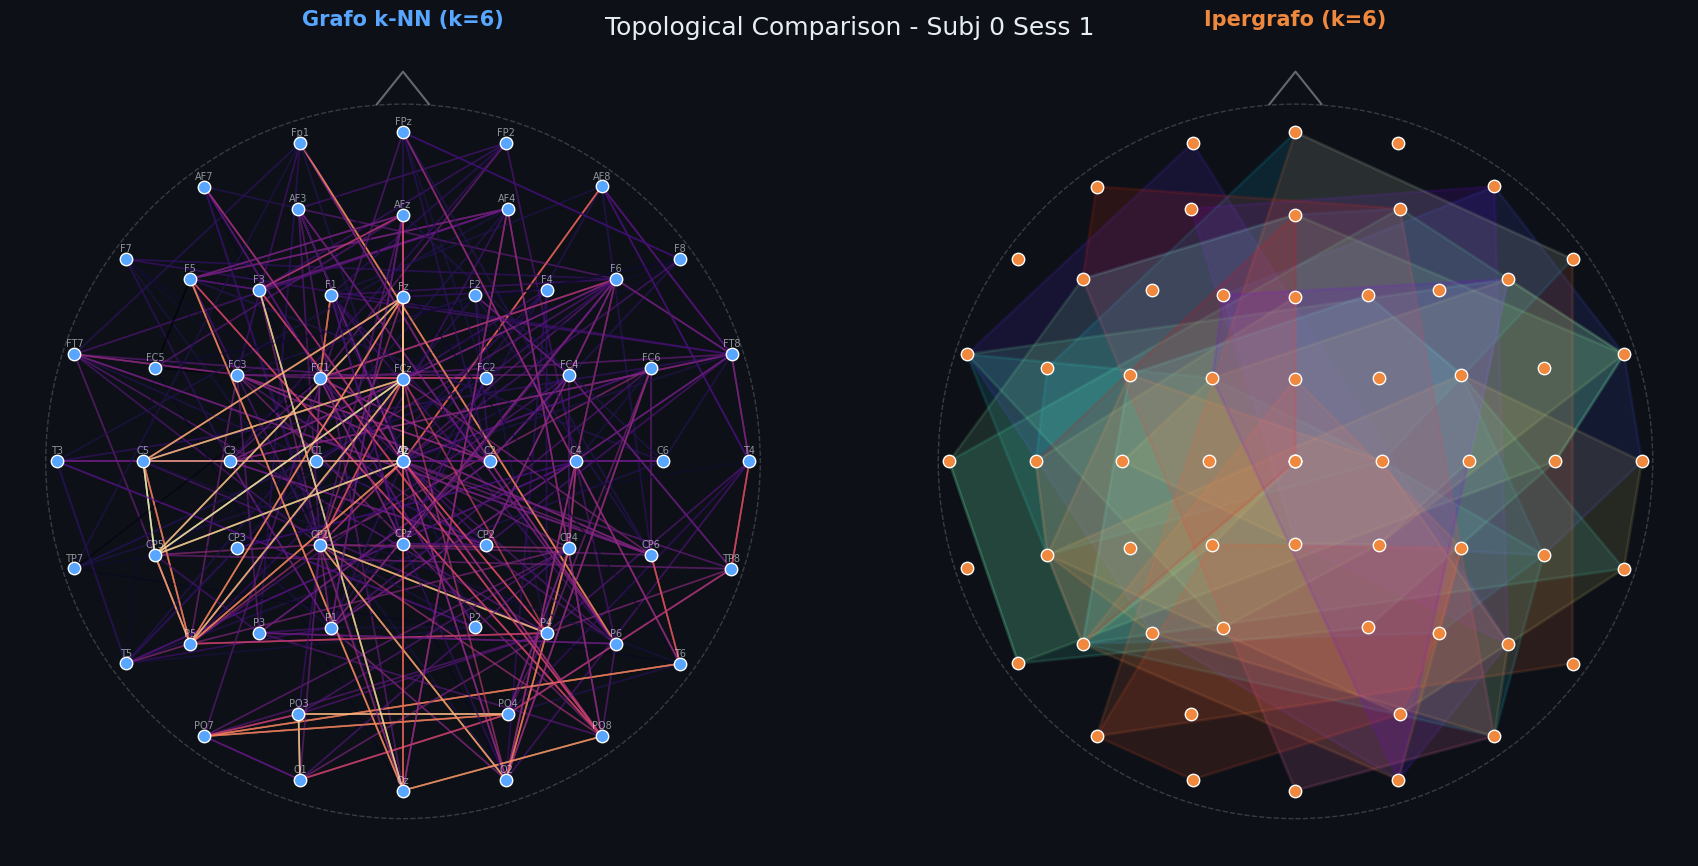

In [ ]:
# ============================================================
# 📊 VIZ: Comparison Grafo k-NN vs Ipergrafo (Topographic)
# ============================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection
from scipy.spatial import ConvexHull

# --- 0. Setup Percorsi e Variabili ---
# Assicurati che questi percorsi siano corretti per il tuo ambiente
ELOC_PATH = project_root / "src" / "io" / "ebneuro.locs" 
# Prendi i file appena creati
GRAPH_PATH = GRAPHS_DIR / f"graph_{METHODS[0]}_k{K_VALUES[0]}.pt"
HGRAPH_PATH = GRAPHS_DIR / f"hgraph_k{K_HYPER}.pt"

def load_eloc_positions(eloc_path):
    names, thetas, radii = [], [], []
    with open(eloc_path) as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) >= 4:
                names.append(parts[3]); thetas.append(float(parts[1])); radii.append(float(parts[2]))
    x = radii * np.sin(np.radians(thetas))
    y = radii * np.cos(np.radians(thetas))
    return names, np.stack([x, y], axis=1)

# --- 1. Caricamento Dati ---
ch_names_all, pos_all = load_eloc_positions(ELOC_PATH)
current_pos = pos_all[active_idx]

g_list = torch.load(GRAPH_PATH, weights_only=False)
h_list = torch.load(HGRAPH_PATH, weights_only=False)
g, hg = g_list[0], h_list[0]

pcc_trial = np.abs(np.corrcoef(g.x.numpy()))
np.fill_diagonal(pcc_trial, 0)

# --- 2. Plotting (Dual Panel) ---
BG_COLOR, TEXT_COLOR = "#0D1117", "#E6EDF3"
plt.rcParams.update({"figure.facecolor": BG_COLOR, "axes.facecolor": BG_COLOR, "text.color": TEXT_COLOR})

fig, axes = plt.subplots(1, 2, figsize=(18, 9))
nose_pts = [-.04, 0, .04], [.55, .60, .55]

# --- Pannello 1: Grafo k-NN ---
ax = axes[0]
ax.set_aspect("equal")
ax.add_patch(plt.Circle((0, 0), 0.55, fill=False, color=TEXT_COLOR, alpha=0.2, linestyle="--"))
ax.plot(nose_pts[0], nose_pts[1], color=TEXT_COLOR, alpha=0.4)

ei = g.edge_index.numpy()
segments = [ [current_pos[i], current_pos[j]] for i, j in ei.T ]
weights = pcc_trial[ei[0], ei[1]]
lc = LineCollection(segments, cmap='magma', alpha=0.4, linewidths=1.2)
lc.set_array(weights)
ax.add_collection(lc)

ax.scatter(current_pos[:, 0], current_pos[:, 1], s=80, c="#58A6FF", edgecolors="white", zorder=3)
for i, txt in enumerate([ch_names_all[idx] for idx in active_idx]):
    ax.annotate(txt, (current_pos[i,0], current_pos[i,1]), fontsize=7, alpha=0.6, xytext=(0,5), textcoords='offset points', ha='center')

ax.set_title(f"Grafo k-NN (k={K_VALUES[0]})", color="#58A6FF", fontsize=15, fontweight="bold")
ax.axis("off")

# --- Pannello 2: Ipergrafo ---
ax = axes[1]
ax.set_aspect("equal")
ax.add_patch(plt.Circle((0, 0), 0.55, fill=False, color=TEXT_COLOR, alpha=0.2, linestyle="--"))
ax.plot(nose_pts[0], nose_pts[1], color=TEXT_COLOR, alpha=0.4)

he_idx = hg.hyperedge_index.numpy()
colors_he = plt.cm.get_cmap('rainbow', 20)

# Visualizziamo una iperedge ogni 3 per non saturare il disegno
for i, he_id in enumerate(range(0, hg.num_hyperedges, 3)):
    nodes = he_idx[0, he_idx[1] == he_id]
    if len(nodes) < 2: continue
    pts = current_pos[nodes]
    color = colors_he(i % 20)
    
    if len(nodes) >= 3:
        try:
            hull = ConvexHull(pts)
            ax.add_patch(plt.Polygon(pts[hull.vertices], alpha=0.12, facecolor=color, edgecolor=color, lw=2))
        except: pass
    else:
        ax.plot(pts[:, 0], pts[:, 1], alpha=0.4, color=color, lw=3)

ax.scatter(current_pos[:, 0], current_pos[:, 1], s=80, c="#F0883E", edgecolors="white", zorder=3)
ax.set_title(f"Ipergrafo (k={K_HYPER})", color="#F0883E", fontsize=15, fontweight="bold")
ax.axis("off")

plt.suptitle(f"Topological Comparison - Subj {g.subj.item()} Sess {g.sess.item()}", fontsize=18, y=0.95)
plt.tight_layout()
plt.show()